In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore", DeprecationWarning)

# plt.rcParams['figure.facecolor'] = 'black'
# plt.rcParams['axes.facecolor'] = 'black'
# plt.rcParams['axes.edgecolor'] = 'white'
# plt.rcParams['axes.labelcolor'] = 'white'
# plt.rcParams['xtick.color'] = 'white'
# plt.rcParams['ytick.color'] = 'white'
# plt.rcParams['text.color'] = 'white'
# plt.rcParams['grid.color'] = 'white'

pathfile=r'/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'
pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
os.chdir(pathfile)

addtotitle='_03022026_AllSubjects' # to specify the version of the data
#_03022026_AllSubjects
behavior_data = pd.read_csv('Subject_preproc' + addtotitle + '.csv')

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

DTI=np.zeros((47, 98, 7))  # 10 DTI metrics
for i, CC in enumerate(CCx_list):
    file_path = os.path.join(pathcsv, f'{CC}_FA{addtotitle}.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    DTI[:,:,i]=dfCCx.values  ## une variable DTI of shape subjects x nodes x n CC

behavior_data['group_encoded']=behavior_data['group'].map({'Y': 0, 'M': 1, 'O': 2}).astype('category')
# Découpage en tertiles
behavior_data['JND_group'] = pd.qcut(behavior_data['JND_P'], q=3, labels=[0,1,2])
behavior_data['JND_group']


0     2
1     1
2     2
3     0
4     0
5     1
6     2
7     1
8     0
9     0
10    0
11    0
12    2
13    2
14    2
15    1
16    0
17    0
18    2
19    1
20    0
21    2
22    2
23    0
24    0
25    2
26    0
27    2
28    1
29    0
30    1
31    1
32    0
33    1
34    1
35    0
36    2
37    1
38    2
39    2
40    2
41    1
42    0
43    2
44    1
45    1
46    1
Name: JND_group, dtype: category
Categories (3, int64): [0 < 1 < 2]

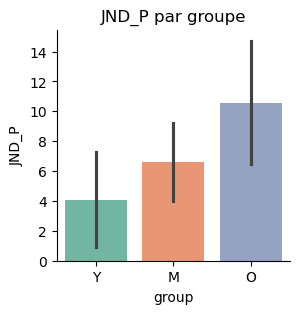

In [134]:
fig, ax = plt.subplots(1, 1, figsize=(3,3))
sns.barplot(data=behavior_data, x='group', y='JND_P',ax=ax, palette='Set2', ci='sd',order=['Y','M','O'])
ax.set_title('JND_P par groupe')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [135]:
from sklearn.cluster import KMeans
import numpy as np

def kmeans_clustering(data, k):
    """
    Effectue le clustering K-means sur les données fournies.

    :param data: Tableau de données à clusteriser
    :param k: Nombre de clusters
    :return: Tuple contenant les centroïdes et les labels des points de données
    """
    # Création du modèle K-means
    kmeans = KMeans(n_clusters=k)

    # Entraînement du modèle
    kmeans.fit(data)

    # Obtention des centroïdes et des labels
    centroids = kmeans.cluster_centers_
    labels = kmeans.labels_

    return centroids, labels


Centroïdes: [[ 0.0966855   0.00782194]
 [-0.24126042 -0.0129865 ]
 [ 0.50962717  0.02070118]]
Labels: [1 1 1 0 1 0 0 0 0 1 1 1 0 1 0 1 1 1 0 0 1 0 0 1 1 2 1 2 0 1 1 2 1 1 2 1 2
 2 2 0 0 1 0 0 0 0 1]
Centroïdes: [[-0.24396909  0.00339667]
 [ 0.07530356 -0.00899791]
 [ 0.35125862  0.01597701]]
Labels: [1 0 0 1 0 2 1 1 1 0 0 0 1 0 1 0 0 0 1 1 0 1 2 0 1 2 1 2 1 1 0 2 0 1 2 0 2
 2 1 1 1 0 1 1 1 0 0]
Centroïdes: [[ 0.07338829  0.00433358]
 [ 0.31695714 -0.01272992]
 [-0.22648951  0.0006019 ]]
Labels: [0 2 2 0 2 1 0 0 0 0 2 2 0 2 0 2 2 2 2 0 2 0 1 2 0 1 0 0 0 0 2 1 2 0 1 2 1
 1 0 0 0 2 0 1 0 2 2]
Centroïdes: [[ 0.02241806 -0.04210349]
 [ 0.31235194  0.04541031]
 [-0.19305569  0.02796945]]
Labels: [0 2 2 0 2 0 0 2 0 2 2 2 0 2 0 2 0 2 2 0 2 0 1 2 0 1 0 1 2 0 2 1 0 0 1 0 1
 1 1 1 0 2 0 0 0 0 2]
Centroïdes: [[ 0.26992161 -0.03682106]
 [-0.21709247 -0.05161145]
 [-0.01796606  0.07889871]]
Labels: [2 1 1 2 1 0 0 1 2 1 1 1 2 1 2 2 2 1 2 0 1 2 0 1 2 0 2 0 2 2 1 0 2 2 0 1 0
 0 0 0 0 1 2 0 2 1 1]
Centr

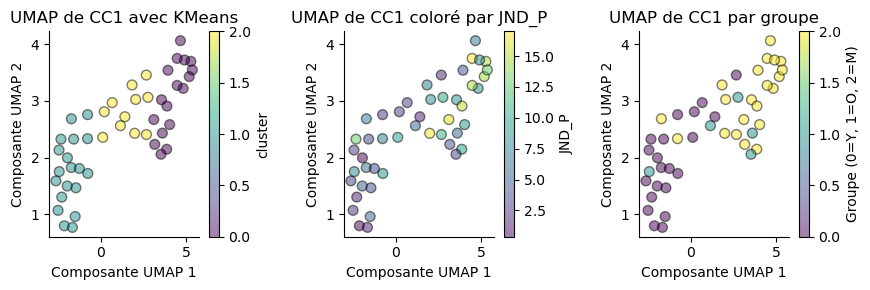

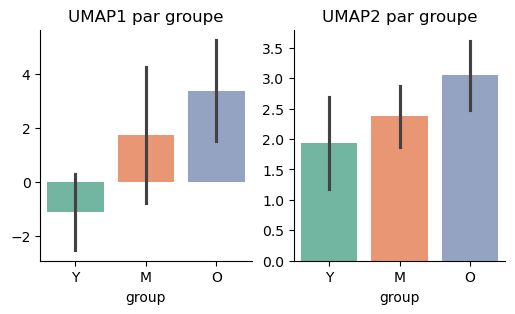

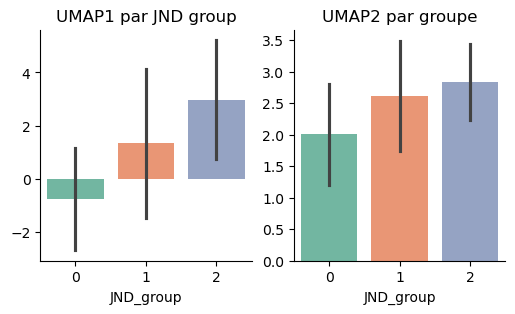

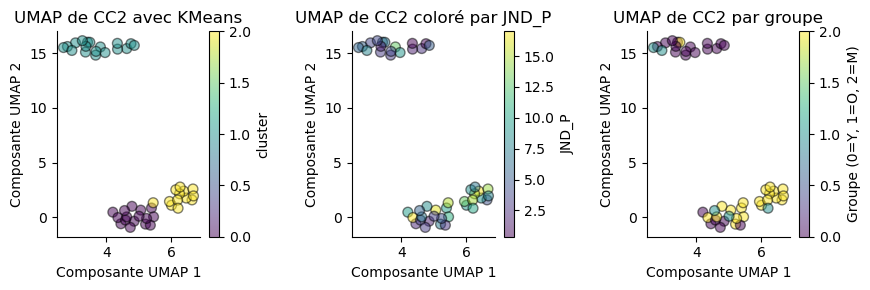

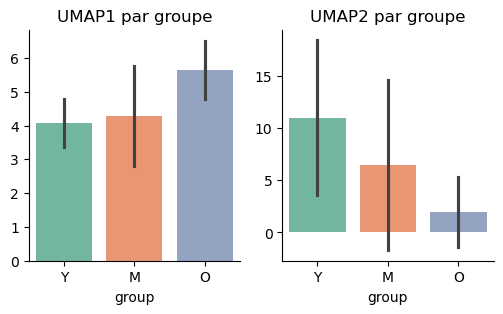

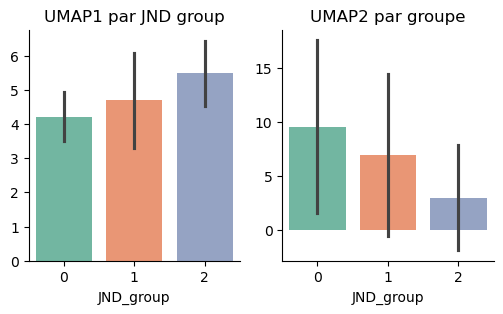

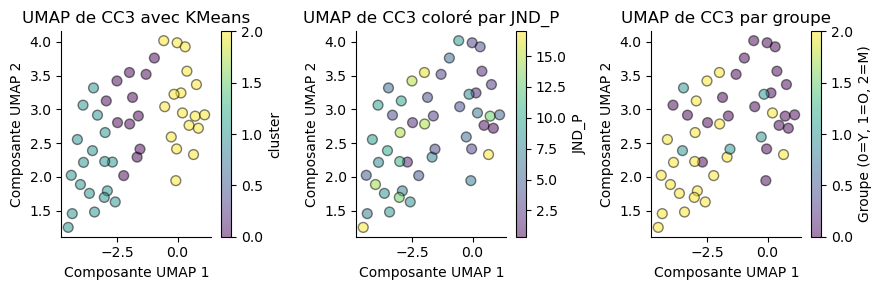

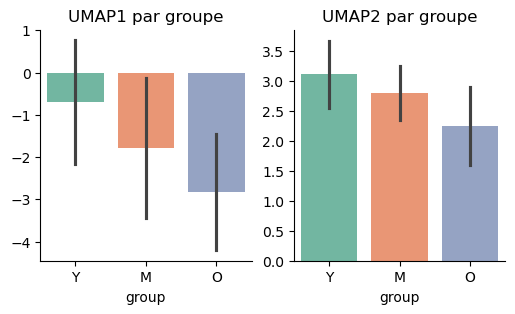

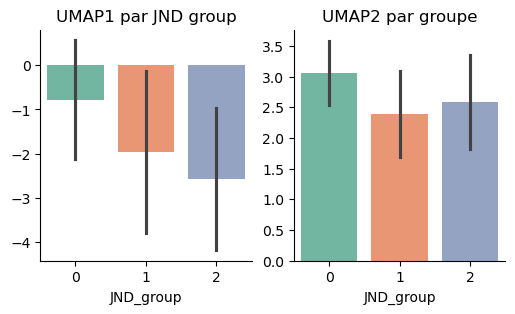

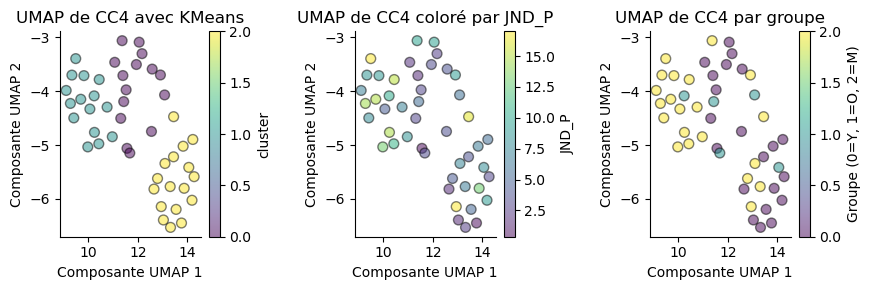

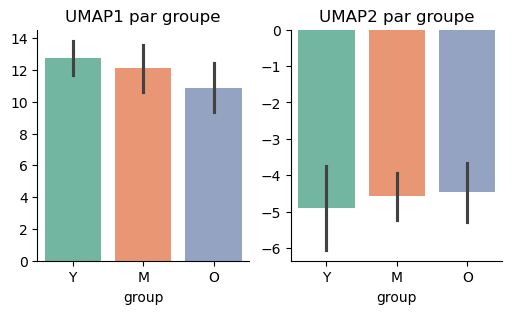

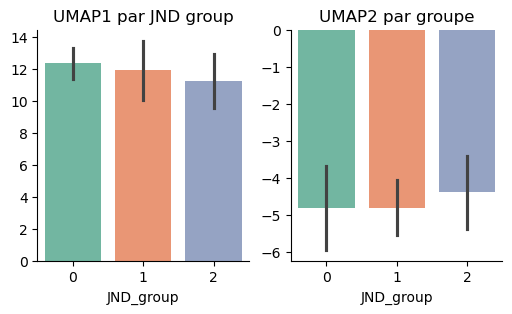

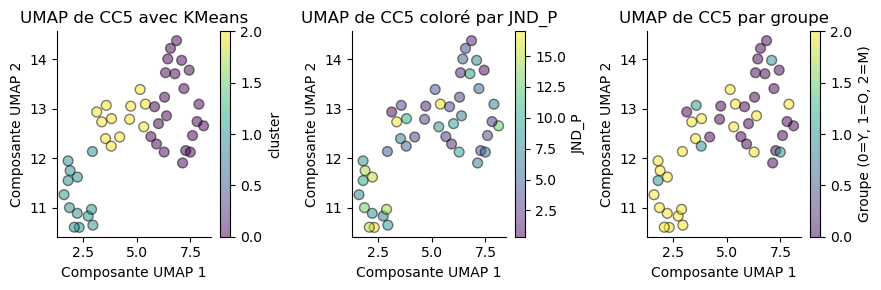

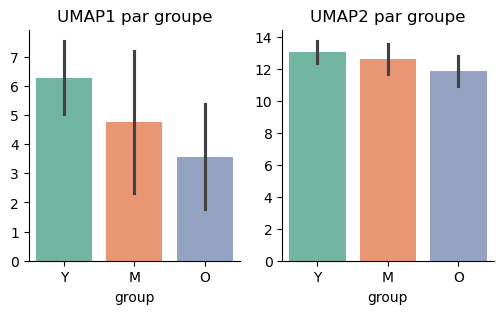

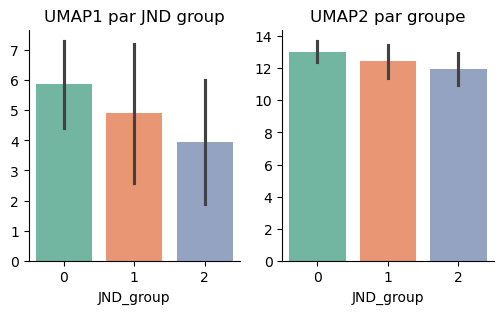

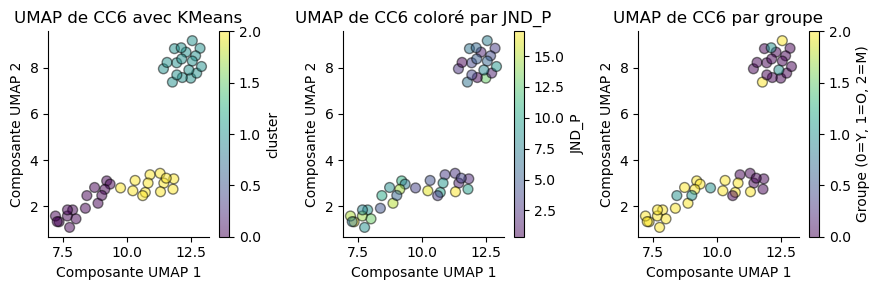

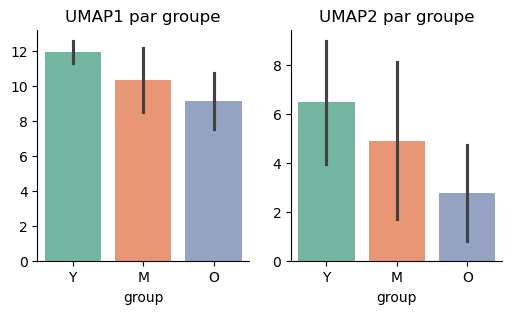

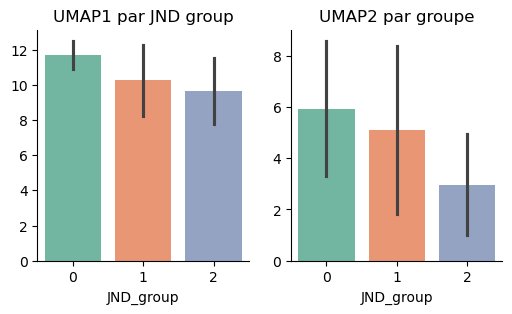

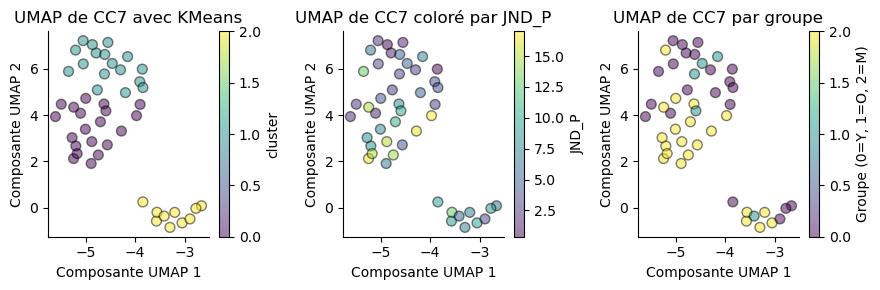

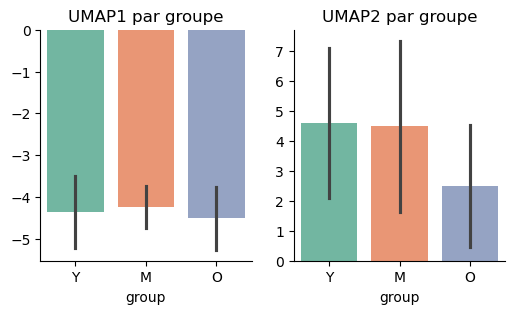

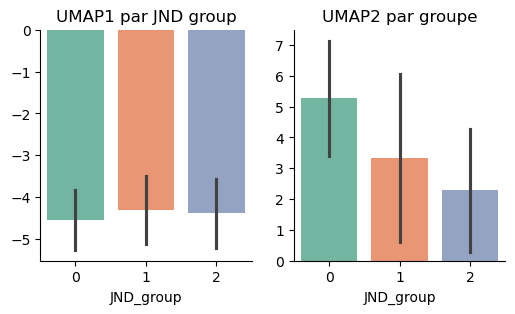

In [140]:

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import umap
from sklearn.preprocessing import StandardScaler

umap_all = []  # Liste pour stocker les UMAP1 de tous les sujets pour chaque CC
for cc in range(7):
    data = DTI[:,:,cc]  # Utiliser les 98 premières colonnes pour le clustering

# Exemple de données

    # Création du modèle PCA
    pca = PCA(n_components=2)  # Réduire à 1 composante principale
    # Application de la PCA sur les données
    data_pca = pca.fit_transform(data)
    # Affichage des composantes principales
    # print("Composantes principales:", principal_components)

    k = 3  # Nombre de clusters
    centroids, labelskmeans = kmeans_clustering(data_pca, k)
    print("Centroïdes:", centroids)
    print("Labels:", labelskmeans)

    # fig, ax = plt.subplots(1,3,figsize=(9,3))

    # ax[0].scatter(data_pca[:, 0], data_pca[:, 1], s=50, c=behavior_data['JND_P'].values, alpha=0.8, edgecolor='k')
    # ax[0].set_title('PCA colored by JND_P')
    # ax[0].set_xlabel('Composante principale 1')
    # ax[0].set_ylabel('Composante principale 2')
    # ax[0].spines['top'].set_visible(False)
    # ax[0].spines['right'].set_visible(False)
    # fig.colorbar(ax[0].collections[0], ax=ax[0], label='JND')

    # ax[1].scatter(data_pca[:, 0], data_pca[:, 1], s=50, c=behavior_data['group_encoded'].values, alpha=0.8, edgecolor='k')
    # ax[1].set_title('PCA colored by age')
    # ax[1].set_xlabel('Composante principale 1')
    # ax[1].set_ylabel('Composante principale 2')
    # ax[1].spines['top'].set_visible(False)
    # ax[1].spines['right'].set_visible(False)
    # fig.colorbar(ax[1].collections[0], ax=ax[1], label='Groupe (0=Y, 1=O, 2=M)')

    # ax[2].scatter(data_pca[:, 0], data_pca[:, 1], s=50, c=labelskmeans, alpha=0.5, edgecolor='k')
    # ax[2].set_title('PCA colored by kmeans labels')
    # ax[2].set_xlabel('Composante principale 1')
    # ax[2].set_ylabel('Composante principale 2')
    # ax[2].spines['top'].set_visible(False)
    # ax[2].spines['right'].set_visible(False)
    # fig.colorbar(ax[2].collections[0], ax=ax[2], label='cluster')


    # plt.tight_layout()



    # Réduction à 2 dimensions avec UMAP
    reducer = umap.UMAP(random_state=42)
        
    X = data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_umap = reducer.fit_transform(X_scaled)
    k=3
    centroids, labelskmeans = kmeans_clustering(X_umap, k)

    fig, ax = plt.subplots(1, 3, figsize=(9,3))
    # Visualisation
    ax[0].scatter(X_umap[:, 0], X_umap[:, 1], s=50, alpha=0.5, edgecolor='k',c=labelskmeans)
    ax[0].set_xlabel('Composante UMAP 1')
    ax[0].set_ylabel('Composante UMAP 2')
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    ax[0].set_title(f'UMAP de CC{cc+1} avec KMeans')
    fig.colorbar(ax[0].collections[0], ax=ax[0], label='cluster')

    ax[1].scatter(X_umap[:, 0], X_umap[:, 1], s=50, alpha=0.5, edgecolor='k',c=behavior_data['JND_P'].values)
    ax[1].set_xlabel('Composante UMAP 1')
    ax[1].set_ylabel('Composante UMAP 2')
    ax[1].spines['top'].set_visible(False)  
    ax[1].spines['right'].set_visible(False)
    ax[1].set_title(f'UMAP de CC{cc+1} coloré par JND_P')
    fig.colorbar(ax[1].collections[0], ax=ax[1], label='JND_P')

    ax[2].scatter(X_umap[:, 0], X_umap[:, 1], s=50, alpha=0.5, edgecolor='k',c=behavior_data['group_encoded'].values)
    ax[2].set_xlabel('Composante UMAP 1')
    ax[2].set_ylabel('Composante UMAP 2')
    ax[2].spines['top'].set_visible(False)  
    ax[2].spines['right'].set_visible(False)
    ax[2].set_title(f'UMAP de CC{cc+1} par groupe')
    fig.colorbar(ax[2].collections[0], ax=ax[2], label='Groupe (0=Y, 1=O, 2=M)')


    plt.tight_layout()

    fig, ax = plt.subplots(1, 2, figsize=(6,3))
    sns.barplot(x=behavior_data['group'], y=X_umap[:, 0],ax=ax[0], palette='Set2', ci='sd',order=['Y','M','O'])
    ax[0].set_title('UMAP1 par groupe')
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    sns.barplot(x=behavior_data['group'], y=X_umap[:, 1],ax=ax[1], palette='Set2', ci='sd',order=['Y','M','O'])
    ax[1].set_title('UMAP2 par groupe')
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)


    fig, ax = plt.subplots(1, 2, figsize=(6,3))
    sns.barplot(x=behavior_data['JND_group'], y=X_umap[:, 0],ax=ax[0], palette='Set2', ci='sd',order=[0,1,2])
    ax[0].set_title('UMAP1 par JND group')
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    
    sns.barplot(x=behavior_data['JND_group'], y=X_umap[:, 1],ax=ax[1], palette='Set2', ci='sd',order=[0,1,2])
    ax[1].set_title('UMAP2 par groupe')
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)

    if cc==0:
        umap_df = pd.DataFrame(X_umap, columns=[f'UMAP1_{cc+1}', f'UMAP2_{cc+1}'])
    umap_df[f'UMAP1_{cc+1}'] = X_umap[:, 0]
    

In [ ]:
umap_df

,UMAP1_1,UMAP2_1,UMAP1_2,UMAP2_2,UMAP1_3,UMAP2_3,UMAP1_4,UMAP2_4,UMAP1_5,UMAP2_5,UMAP1_6,UMAP2_6,UMAP1_7,UMAP2_7
0,0.118391,2.358084,4.201163,0.454719,-3.911530,3.063455,12.048654,-3.089295,6.013924,12.700310,11.795034,2.734265,-3.845527,0.251510
1,-1.724373,1.824547,3.423373,16.022419,-0.071945,1.945324,13.825333,-5.022598,7.134014,11.906383,11.852771,8.829789,-2.660288,0.085694
2,-2.326262,2.326239,3.817682,15.592524,0.726920,2.900578,13.866445,-5.804060,8.109217,12.656703,12.491288,7.550355,-5.347204,5.894926
3,2.665536,3.458168,4.449336,-0.605185,-2.482887,2.804600,11.061873,-3.463140,5.922493,12.289175,11.826474,3.182854,-5.611641,3.941047
4,-2.496652,1.069038,4.629121,15.444678,0.780418,3.368652,13.315690,-6.530423,7.805116,12.742048,11.422304,7.956633,-5.053003,7.223516
5,3.933767,3.542521,6.638051,1.580362,-4.398087,2.024955,10.057466,-4.331201,2.939479,12.137724,8.377638,1.907014,-4.563177,2.718488
6,3.859087,2.148230,5.389449,0.838639,-2.949653,3.126103,11.359692,-3.061384,6.274742,12.126866,10.715110,2.595249,-3.053106,-0.654104
7,1.831299,3.283078,5.208503,-0.641165,-1.674299,2.293735,13.091674,-5.343038,7.891227,13.092816,12.548538,9.175723,-3.201328,-0.200425
8,1.412182,2.721856,4.854445,-0.375580,-2.695264,2.220373,11.391164,-3.709401,4.722889,13.054080,11.438376,3.000202,-5.104296,4.085798
9,-1.585138,2.326929,3.051640,15.965466,-1.863285,3.178120,12.546211,-4.747920,7.596201,12.460400,11.939748,8.216115,-5.049181,6.219488


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import random
from scipy.stats import ttest_ind
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR

X=umap_df.values


for target in ['JND_P', 'age']:
    y=behavior_data[target].values

    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, min_samples_split=2, max_depth=None, random_state=42),
        'SVM': make_pipeline(StandardScaler(), SVR(kernel='linear'))
    }

    # Définir la grille de paramètres
    param_grid = {
        'n_estimators': [50, 100],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }

    # Évaluer chaque modèle avec validation croisée
    for name, model in models.items():
        scores = cross_val_score(model, X, y, cv=5, scoring='r2')
        print(f"{name} : R² moyen = {np.mean(scores):.3f} ± {np.std(scores):.3f}")






Linear Regression : R² moyen = 0.111 ± 0.394
Random Forest : R² moyen = -0.231 ± 0.353
SVM : R² moyen = 0.085 ± 0.343
Linear Regression : R² moyen = 0.503 ± 0.194
Random Forest : R² moyen = 0.492 ± 0.263
SVM : R² moyen = 0.506 ± 0.234


<Axes: xlabel='UMAP1_1', ylabel='UMAP1_7'>

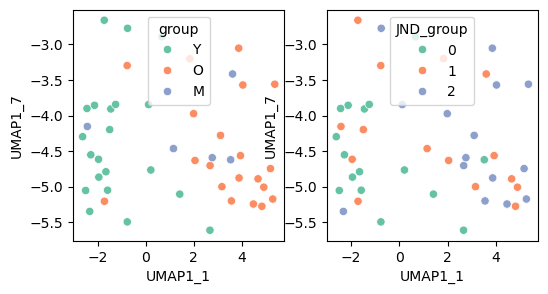

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(6,3))


cc1=1
cc2=7
sns.scatterplot(x=umap_df[f'UMAP1_{cc1}'], y=umap_df[f'UMAP1_{cc2}'], hue=behavior_data['group'], palette='Set2', ax=ax[0])
sns.scatterplot(x=umap_df[f'UMAP1_{cc1}'], y=umap_df[f'UMAP1_{cc2}'], hue=behavior_data['JND_group'], palette='Set2', ax=ax[1])

In [ ]:
behavior_data

,sub,age,group,JND_P,group_M,group_O,group_Y,group_encoded,JND_group
0,sub-01,25,Y,9.5600,0.0,0.0,1.0,0,2
1,sub-02,27,Y,6.6900,0.0,0.0,1.0,0,1
2,sub-03,28,Y,12.9200,0.0,0.0,1.0,0,2
3,sub-05,21,Y,1.9500,0.0,0.0,1.0,0,0
4,sub-06,25,Y,2.5400,0.0,0.0,1.0,0,0
5,sub-08,67,O,4.4800,0.0,1.0,0.0,2,1
6,sub-09,73,O,9.6300,0.0,1.0,0.0,2,2
7,sub-10,64,O,7.2700,0.0,1.0,0.0,2,1
8,sub-11,21,Y,1.6200,0.0,0.0,1.0,0,0
9,sub-12,21,Y,3.6800,0.0,0.0,1.0,0,0


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import confusion_matrix    
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, KFold

age_grouped = behavior_data['group_encoded'].values
jnd_grouped = behavior_data['JND_group'].values

X=umap_df.values

skf = StratifiedKFold(n_splits=5,shuffle=True)
scaler = RobustScaler()



[[19  0  2]
 [ 2  0  3]
 [ 5  0 16]]
0
[[12  2  2]
 [ 7  2  6]
 [ 7  3  6]]
1


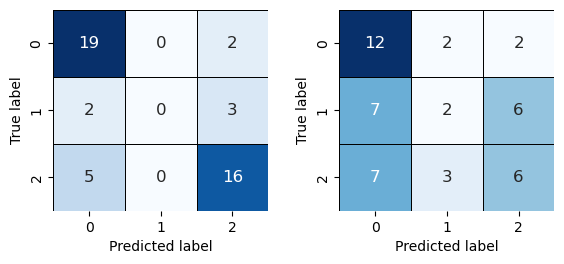

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(6,3))

for i, groupe in enumerate(['age','jnd']):
    if groupe=='age':
        y=age_grouped
        sizecm=3
    elif groupe=='jnd':
        y=jnd_grouped
        sizecm=3

    X_scaled = scaler.fit_transform(X)

    CM=np.zeros((sizecm, sizecm), dtype=int)
    for train, test in skf.split(X_scaled, y):

        # print("TRAIN:", train, "TEST:", test)


        X_train, X_test = X_scaled[train], X_scaled[test]
        y_train, y_test = y[train], y[test]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)


        n_neighbors = 3
        nbrs = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X_train_scaled, y_train)

        y_pred = nbrs.predict(X_test_scaled)
        # print(classification_report(y_test, y_pred))
        cm = confusion_matrix(y_test, y_pred)
        if cm.shape==(sizecm, sizecm):
            CM+=cm

    sns.heatmap(CM, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axs[i], annot_kws={"size": 12},linewidths=0.5, linecolor='black')
    axs[i].set_xlabel('Predicted label')
    axs[i].set_ylabel('True label')


    print(CM)
    print(i)
plt.tight_layout(pad=2.0 )
plt.show()



In [ ]:
y

array([0, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 2, 0, 2, 2, 0, 0, 2, 2, 0, 2,
       2, 0, 0, 2, 0, 2, 2, 0, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2, 0, 1, 1,
       1, 1, 1], dtype=int64)